# Lattice plotting

Total energy versus lattice constant

## Article information

Title: Electronic and optical properties of Graphene-Boron-based bilayers: BC3, Borophene, B4C3


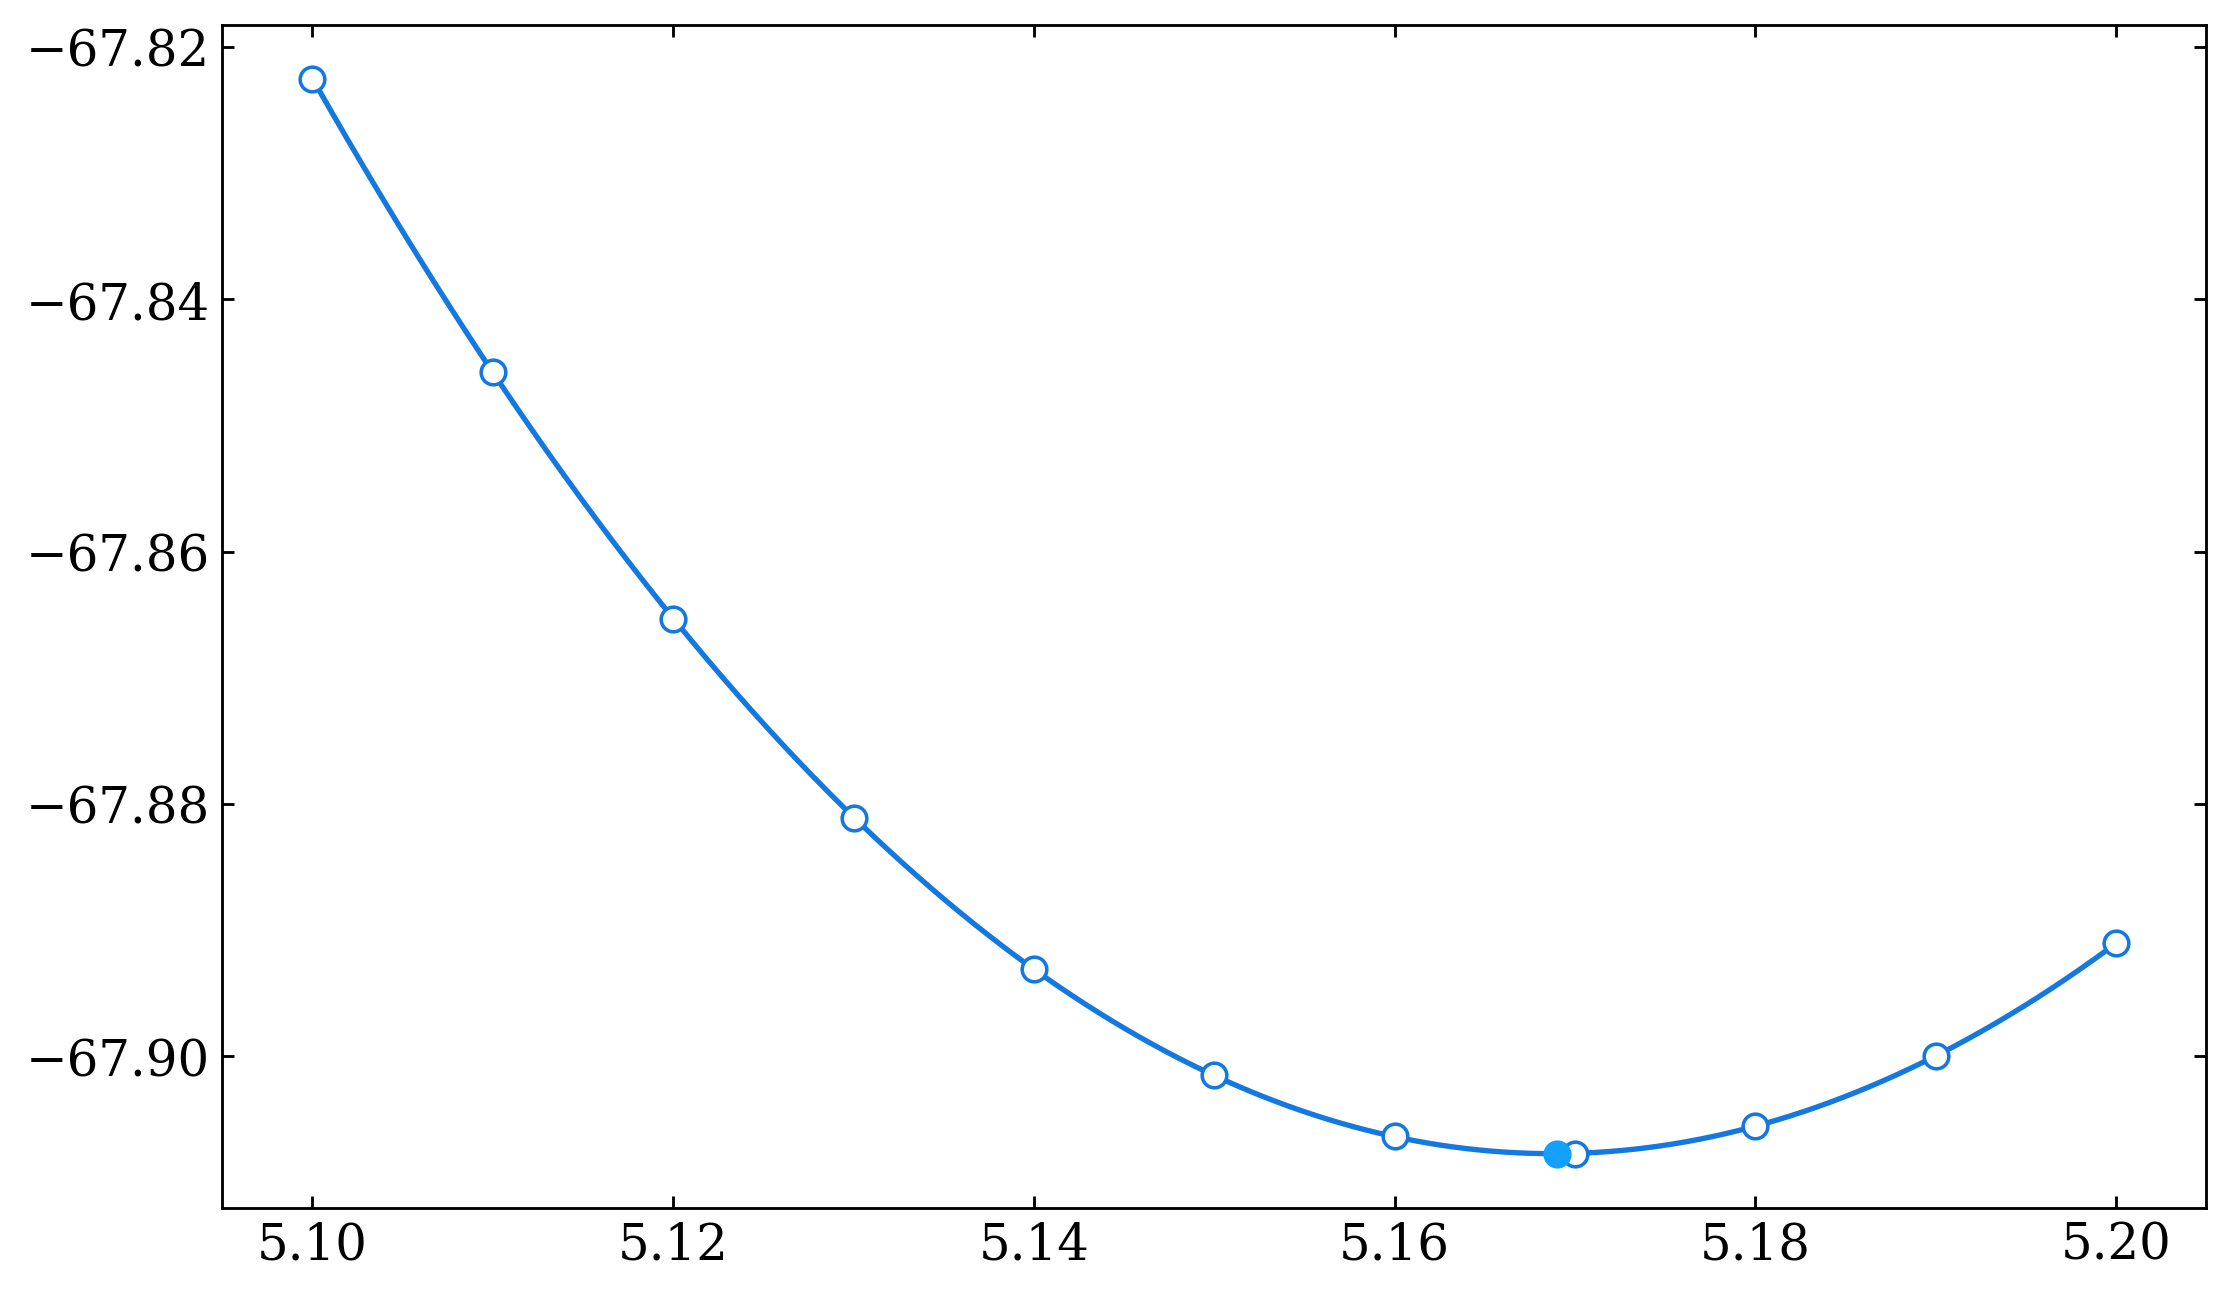

In [1]:
import matplotlib.pyplot as plt

from vmatplot.algorithms import fit_eos
from vmatplot.output import canvas_setting, color_sampling
from vmatplot.lattice import read_free_energy_lattice_count

# from vmatplot.lattice_plotting import

# testing: BC₃

def create_matters_lattice(lattice_list):
    # data = create_matters_lattice(lattice_list)
    # data[0] = current curve label
    # data[1] = lattice and free energy data
        # data[1][0] = lattice values
        # data[1][1] = free energy
    # data[2] = color family
    # data[3] = samples count
    data = []
    for lattice_dir in lattice_list:
        if len(lattice_dir) == 2:
            label, data_path = lattice_dir
            color = "blue"
            nsamp = "all"   # the number of samples
            lattice_data = read_free_energy_lattice_count(data_path, nsamp)
            lattice_tot  = lattice_data
        elif len(lattice_dir) == 3:
            label, data_path, color = lattice_dir
            nsamp = "all"
            lattice_data = read_free_energy_lattice_count(data_path, nsamp)
            lattice_tot  = lattice_data
        elif len(lattice_dir) == 4:
            label, data_path, color, nsamp = lattice_dir
            lattice_data = read_free_energy_lattice_count(data_path, nsamp)
            lattice_tot  = read_free_energy_lattice_count(data_path)
        data.append([label, lattice_data, lattice_tot, color])
    return data

def plot_free_energy_lattice(suptitle, lattice_list = None, lattice_start = None, lattice_end = None):
    # help information
    help_info = "Usage: plot_free_energy_lattice" + \
                "Use summarize_free_energy_lattice_directory to extract the free energy versus lattice into free_energy_lattice.dat firstly.\n"
    if suptitle in ["help", "Help"]:
        print(help_info)

    # figure Settings
    fig_setting = canvas_setting()
    plt.figure(figsize=fig_setting[0], dpi = fig_setting[1])
    params = fig_setting[2]; plt.rcParams.update(params)
    plt.tick_params(direction="in", which="both", top=True, right=True, bottom=True, left=True)

    # plot data
    lattice_info_set = create_matters_lattice(lattice_list)
    for _, lattice_info in enumerate(lattice_info_set):
        # fitted curve
        fitted_lattice, fitted_free_energy = fit_eos(lattice_info[2][0], lattice_info[2][1])
        colors = color_sampling(lattice_info[3])
        plt.plot(fitted_lattice,fitted_free_energy,color=colors[1],zorder=1)
        # scatter
        plt.scatter(lattice_info[1][0], lattice_info[1][1], s=48, fc="#FFFFFF", ec=colors[1], label="Source data", zorder=1)
        # demonstrate the minimum free energy and the corresponding lattice
        energy_min_index = lattice_info[2][1].index(min(lattice_info[2][1]))
        lattice_min = (lattice_info[2][0])[energy_min_index]
        free_energy_min = min(lattice_info[2][1])
        plt.scatter(lattice_min, free_energy_min, s=48, fc=colors[2], ec=colors[2], label="Source lowest point", zorder=1)

lattice_list = [["","0_Lattice/A_BC3/free_energy_lattice.dat","blue", 11]]

plot_free_energy_lattice("B₄C₃",lattice_list, 5.15, 5.2)

In [2]:
# # BC₃

# from vmatplot.lattice import plot_lattice_free_energy

# plot_lattice_free_energy(1, "BC₃", 11, "0_Lattice/A_BC3/lattice_free_energy.dat", "blue")


In [3]:
# # Borophene

# plot_lattice_free_energy(1, "Borophene", 11, "0_Lattice/B_Borophene/lattice_free_energy.dat", "green")


In [4]:
# # B₄C₃

# plot_lattice_free_energy(1, "B₄C₃", 11, "0_Lattice/C_B4C3/lattice_free_energy.dat", "violet")


In [5]:
# # Graphene

# # summarize_lattice_free_energy_directory("0_Lattice/D_Graphene")

# plot_lattice_free_energy(1, "Graphene", 11, "0_Lattice/D_Graphene/lattice_free_energy.dat", "grey")


In [6]:
# # Graphene - BC₃

# plot_lattice_free_energy(3, "Graphene-BC₃", 11,
#                          "Top", "0_Lattice/E_Graphene-BC3_Top/lattice_free_energy.dat", "blue", 
#                          "Bridge", "0_Lattice/E_Graphene-BC3_Bridge/lattice_free_energy.dat", "green",
#                          "Hollow", "0_Lattice/E_Graphene-BC3_Hollow/lattice_free_energy.dat", "violet",
#                          )


In [7]:
# # Graphene - Borophene

# plot_lattice_free_energy(4, "Graphene-Borophene", 11,
#                          "Top", "0_Lattice/F_Graphene-Borophene_Top/lattice_free_energy.dat", "blue", 
#                          "Bridge", "0_Lattice/F_Graphene-Borophene_Bridge/lattice_free_energy.dat", "green",
#                          "Hollow 1", "0_Lattice/F_Graphene-Borophene_Hollow1/lattice_free_energy.dat", "violet",
#                          "Hollow 2", "0_Lattice/F_Graphene-Borophene_Hollow2/lattice_free_energy.dat", "purple",
#                          )


In [8]:
# # Graphene - B₄C₃

# plot_lattice_free_energy(4, "Graphene-B₄C₃", 11,
#                          "Top", "0_Lattice/G_Graphene-B4C3_Top/lattice_free_energy.dat", "blue", 
#                          "Bridge", "0_Lattice/G_Graphene-B4C3_Bridge/lattice_free_energy.dat", "green",
#                          "Hollow 1", "0_Lattice/G_Graphene-B4C3_Hollow1/lattice_free_energy.dat", "violet",
#                          "Hollow 2", "0_Lattice/G_Graphene-B4C3_Hollow2/lattice_free_energy.dat", "purple",
#                          )